## Simulating traffic around a lock
In this notebook, we simulate a lock on a network which two opposingly directed vessels have to pass. We add a pre-coded complex lock object on the graph: only one vessel can be levelled at a time. The second vessel waits until the first vessel has passed the lock. 

#### 0. Import libraries

In [1]:
# package(s) used for creating and geo-locating the graph
import networkx as nx
import pyproj
from shapely.geometry import Point, LineString
from shapely.ops import transform

# package(s) related to the simulation (creating the vessel, running the simulation)
import datetime
import simpy
import opentnsim
from opentnsim.core.logutils import logbook2eventtable
from opentnsim.core.plotutils import generate_vessel_gantt_chart
import numpy as np
from scipy.stats import norm, uniform, expon

# import of modules important for locking
from opentnsim.lock import lock_new as lock_module
from opentnsim import vessel_traffic_service as vessel_traffic_service_module

# package(s) needed for inspecting the output
import pandas as pd
import matplotlib.pyplot as plt

print("This notebook is executed with OpenTNSim version {}".format(opentnsim.__version__))

This notebook is executed with OpenTNSim version 1.3.7


#### 1. Define object classes

In [2]:
# make your preferred Vessel class out of available mix-ins.
Vessel = type(
    "Vessel", 
    (
        lock_module.PassesLockComplex,             # allows to interact with a lock
        opentnsim.core.Identifiable,               # allows to give the object a name and a random ID,
        opentnsim.core.Movable,                    # allows the object to move, with a fixed speed, while logging this activity
        opentnsim.core.VesselProperties,           # allows vessel to have dimensions, namely a length (L), width (B), and draught (T)
        opentnsim.core.ExtraMetadata,              # allow additional information, such as an arrival time (required for passing a lock)
        opentnsim.graph.HasMultiDiGraph,           # allow to operate on a graph that can include parallel edges from and to the same nodes
        opentnsim.output.HasOutput,                # allow additional output to be stored
    ), 
    {}
)

#### 2. Create graph

In [3]:
# define reference systems
wgs84eqd = pyproj.CRS('4087')
wgs84rad = pyproj.CRS('4326')

# define transformer functions
wgs84eqd_to_wgs84rad = pyproj.transformer.Transformer.from_crs(wgs84eqd,wgs84rad,always_xy=True).transform #equidistant wgs84 to radial wgs84
wgs84rad_to_wgs84eqd = pyproj.transformer.Transformer.from_crs(wgs84rad,wgs84eqd,always_xy=True).transform #radial wgs84 to equidistant wgs84

# create a directed graph
graph = nx.DiGraph()

# add nodes
graph.add_node('-1',geometry=transform(wgs84eqd_to_wgs84rad,Point(-350600,0)))
graph.add_node('0',geometry=transform(wgs84eqd_to_wgs84rad,Point(-5000,0)))
graph.add_node('1',geometry=transform(wgs84eqd_to_wgs84rad,Point(5000,0)))
graph.add_node('+1',geometry=transform(wgs84eqd_to_wgs84rad,Point(350600,0)))

# add edges
graph.add_edge('-1','0', weight=1)
graph.add_edge('0','-1', weight=1)
graph.add_edge('0','1', weight=1)
graph.add_edge('1','0', weight=1)
graph.add_edge('1','+1', weight=1)
graph.add_edge('+1','1', weight=1)


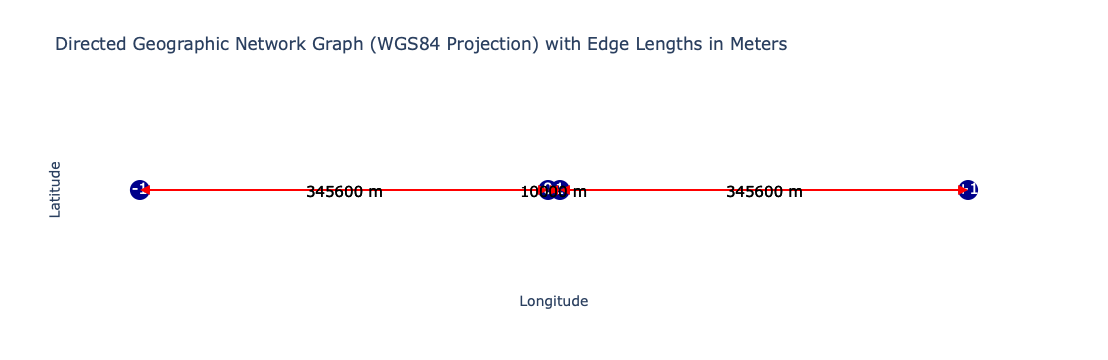

In [4]:
opentnsim.graph.plot_graph(graph)

#### 3. Run simulation

In [5]:
def generate_vessel(
    env,
    name,
    start_node,
    end_node,
    arrival_time,
    vessel_speed=4,
    vessel_length=100,
    vessel_beam=20,
    vessel_draft=10,
    vessel_type="tanker"):
    """
    Creates and returns a Vessel object with a computed route through the environment graph.

    Parameters:
    ----------
    env : Environment
        The simulation environment containing the graph and other context.
    name : str
        Unique identifier for the vessel.
    start_node : str or int
        The starting node in the graph (converted to string).
    end_node : str or int
        The destination node in the graph (converted to string).
    arrival_time : pd.Timestamp
        The scheduled arrival time of the vessel at the start node.
    vessel_speed : float, optional
        Speed of the vessel in knots or simulation units (default is 4).
    vessel_length : float, optional
        Length of the vessel in meters (default is 100).
    vessel_beam : float, optional
        Beam (width) of the vessel in meters (default is 20).
    vessel_draft : float, optional
        Draft (depth below waterline) of the vessel in meters (default is 10).
    vessel_type : str, optional
        Type of vessel (e.g., "tanker", "cargo", "container") (default is "tanker").

    Returns:
    -------
    Vessel or None
        A Vessel object initialized with the given parameters and route.
        Returns None if no valid path exists between start_node and end_node.
    """
    
    # Ensure nodes are strings
    start_node = str(start_node)
    end_node = str(end_node)

    try:
        route = nx.dijkstra_path(env.graph, start_node, end_node)
    except nx.NetworkXNoPath:
        print(f"⚠️ No path from {start_node} to {end_node}. Vessel {name} not created.")
        return None

    geometry = env.graph.nodes[start_node]['geometry']

    data_vessel = {
        "env": env,
        "name": name,
        "geometry": geometry,
        "route": route,
        "v": vessel_speed,
        "L": vessel_length,
        "B": vessel_beam,
        "T": vessel_draft,
        "type": vessel_type,
        "arrival_time": arrival_time,
    }

    vessel = Vessel(**data_vessel)

    return vessel

In [6]:
def generate_vessels_with_distributions(
    env,
    num_vessels,
    start_time,
    arrival_dist_up=None,
    arrival_dist_down=None,
    seed_up=None,
    seed_down=None
):
    """
    Generates a list of vessels with interarrival times drawn from specified distributions
    for upward and downward directions. Supports independent seeding for reproducibility.

    Parameters
    ----------
    env : Environment
        The simulation environment containing the graph and vessel context.
    num_vessels : int
        Total number of vessels to generate. Vessels alternate between up and down directions.
    start_time : pd.Timestamp
        The initial timestamp from which vessel arrivals begin.
    arrival_dist_up : callable, optional
        A function returning interarrival times (in minutes) for upward-moving vessels.
        If None, defaults to an exponential distribution with mean 20 minutes.
    arrival_dist_down : callable, optional
        A function returning interarrival times (in minutes) for downward-moving vessels.
        If None, defaults to an exponential distribution with mean 20 minutes.
    seed_up : int or None, optional
        Seed for the random number generator used in upward direction.
    seed_down : int or None, optional
        Seed for the random number generator used in downward direction.

    Returns
    -------
    list of Vessel
        A list of Vessel objects with assigned routes and arrival times.
        Vessels for which no valid path exists are skipped.
    """

    vessels = []

    # Create independent random generators
    rng_up = np.random.default_rng(seed_up)
    rng_down = np.random.default_rng(seed_down)

    # Default to exponential distribution with mean 20 minutes
    if arrival_dist_up is None:
        arrival_dist_up = lambda: rng_up.exponential(scale=20)
    if arrival_dist_down is None:
        arrival_dist_down = lambda: rng_down.exponential(scale=20)

    up_time = start_time
    down_time = start_time

    for i in range(num_vessels):
        if i % 2 == 0:
            # Upward direction: -1 → +1
            start_node, end_node = "-1", "+1"
            delta_minutes = arrival_dist_up()
            arrival_time = up_time + pd.Timedelta(minutes=delta_minutes)
            up_time = arrival_time
        else:
            # Downward direction: +1 → -1
            start_node, end_node = "+1", "-1"
            delta_minutes = arrival_dist_down()
            arrival_time = down_time + pd.Timedelta(minutes=delta_minutes)
            down_time = arrival_time

        vessel = generate_vessel(
            env=env,
            name=f"Vessel {i + 1}",
            start_node=start_node,
            end_node=end_node,
            arrival_time=arrival_time
        )

        if vessel:
            vessels.append(vessel)

    return vessels

In [7]:
def mission(env, vessel):
    """
    Method that defines the mission of the vessel.
    
    In this case: 
        keep moving along the path until its end point is reached
    """
    while True:
        yield from vessel.move()
        
        if vessel.geometry == nx.get_node_attributes(env.graph, "geometry")[vessel.route[-1]]:
            break

In [8]:
# start simpy environment
simulation_start = datetime.datetime(2025, 1, 1, 0, 0, 0)
env = simpy.Environment(initial_time=simulation_start.timestamp())
env.epoch = simulation_start

# add graph to environment
env.graph = graph

# add components important for locking to the environment
env.vessel_traffic_service = vessel_traffic_service_module.VesselTrafficService(graph=graph)

lock = lock_module.IsLockComplex(
    env=env,
    name='Lock',
    node_open='0',
    node_A = '0',
    node_B = '1',
    distance_lock_doors_A_to_waiting_area_A = 4800,
    distance_lock_doors_B_to_waiting_area_B = 4800,
    distance_from_start_node_to_lock_doors_A = 4800,
    distance_from_end_node_to_lock_doors_B = 4800,
    lock_length = 400,
    lock_width = 50,
    lock_depth = 15,
    levelling_time = 300,
    sailing_distance_to_crossing_point = 1800,
    doors_opening_time= 300,
    doors_closing_time= 300,
    speed_reduction_factor_lock_chamber=0.5,
    sailing_in_time_gap_through_doors = 300,
    sailing_in_speed_sea = 1.5,
    sailing_in_speed_canal = 1.5,
    sailing_out_time_gap_through_doors = 120,
    sailing_time_before_opening_lock_doors = 600,
    sailing_time_before_closing_lock_doors = 120,
    registration_nodes = ['-1','+1'],
)

start_time = pd.Timestamp('2025-01-01 00:00:00')

# Custom distributions
arrival_dist_up = lambda: norm(loc=25, scale=5).rvs(random_state=np.random.default_rng(123))
arrival_dist_down = lambda: uniform(loc=10, scale=10).rvs(random_state=np.random.default_rng(456))

vessels = generate_vessels_with_distributions(
    env=env,
    num_vessels=10,
    start_time=start_time,
    arrival_dist_up=arrival_dist_up,
    arrival_dist_down=arrival_dist_down,
    seed_up=123,
    seed_down=456
)

# Example using numpy
# Create independent random generators
rng_up = np.random.default_rng(123)
rng_down = np.random.default_rng(456)

# Exponential distributions with different means (scale = mean)
arrival_dist_up = lambda: rng_up.exponential(scale=30)   # mean 30 minutes
arrival_dist_down = lambda: rng_down.exponential(scale=15)  # mean 15 minutes

# # Example using scipy.stats
# # Create independent random generators
# rng_up = np.random.default_rng(123)
# rng_down = np.random.default_rng(456)

# # Exponential distributions using SciPy
# arrival_dist_up = lambda: expon(scale=30).rvs(random_state=rng_up)
# arrival_dist_down = lambda: expon(scale=15).rvs(random_state=rng_down)

vessels = generate_vessels_with_distributions(
    env=env,
    num_vessels=40,
    start_time=start_time,
    arrival_dist_up=arrival_dist_up,
    arrival_dist_down=arrival_dist_down,
    seed_up=123,
    seed_down=456
)

for vessel in vessels:
    env.process(mission(env, vessel))

env.run()

Vessel 2 2025-01-01 00:07:22.177207 new
Vessel 4 2025-01-01 00:13:40.580269 planned
Vessel 6 2025-01-01 00:17:13.532738 planned
Vessel 1 2025-01-01 00:17:54.550491 new
Vessel 3 2025-01-01 00:21:25.206401 planned
Vessel 8 2025-01-01 00:24:37.704947 planned
Vessel 8 Vessel 1 0 days 00:07:57.124678
Vessel 8 Vessel 3 0 days 00:07:57.124678
Vessel 5 2025-01-01 00:28:58.436860 planned
Vessel 7 2025-01-01 00:38:12.774662 planned
Vessel 9 2025-01-01 00:40:58.019450 new
Vessel 10 2025-01-01 01:03:33.671764 new
Vessel 12 2025-01-01 01:04:18.150428 planned
Vessel 14 2025-01-01 01:07:47.987086 planned
Vessel 11 2025-01-01 01:51:30.936990 planned
Vessel 11 Vessel 10 0 days 00:06:02.980561764
Vessel 11 Vessel 12 0 days 00:06:02.980561764
Vessel 11 Vessel 14 0 days 00:06:02.980561764
Vessel 16 2025-01-01 01:55:15.583328 planned
Vessel 18 2025-01-01 02:09:14.395738 new
Vessel 20 2025-01-01 02:16:55.917207 planned
Vessel 22 2025-01-01 02:31:51.689261 planned
Vessel 24 2025-01-01 03:10:01.968400 planned

In [9]:
n_max = 4
vessel_speed_outside_of_lock = 4

# Part III, Ch3, Eq. 3.2 (NB: de helft van de looptime wordt hier effectief geimplementeerd door de sailing to lock te berekenen)
t_sailing_to_lock = lock.sailing_distance_to_crossing_point/vessel_speed_outside_of_lock
T_entering = t_sailing_to_lock + (n_max-1)*lock.sailing_in_time_gap_through_doors + 50/2

# Part III, Ch3, Eq. 3.3
T_operation = lock.doors_closing_time + lock.levelling_time + lock.doors_opening_time

# Part III, Ch3, Eq. 3.4 (NB: de helft van de looptime wordt hier effectief geimplementeerd door de sailing out of lock te berekenen)
t_sailing_out_of_lock = lock.sailing_distance_to_crossing_point/vessel_speed_outside_of_lock
T_exiting = t_sailing_out_of_lock + (n_max-1)*lock.sailing_out_time_gap_through_doors + 350/2

# Part III, Ch3, Eq. 3.1
T_locking = T_entering + T_operation + T_exiting
T_c = 2 * T_locking

C_s = 2*n_max / (T_c/3600)

print(f"The capacity of the lock is {np.round(C_s,1)} vessels per hour")

The capacity of the lock is 4.4 vessels per hour


In [10]:
IC = 1
T_arrival = T_locking*(1/IC)

In [11]:
predicted_arrival_moments = pd.date_range(simulation_start+pd.Timedelta(seconds=3000/4),simulation_start+pd.Timedelta(days=1),freq=pd.Timedelta(seconds=T_arrival))



#### 4. Inspect output

In [12]:
# load the logbook data into a dataframe
lock_df = pd.DataFrame.from_dict(lock.logbook)

print("'{}' logbook data:".format(lock.name))  
print('')

display(lock_df)

'Lock' logbook data:



,Message,Timestamp,Value,Geometry
0,Lock doors closing start,2025-01-01 00:07:22.177207,{},0
1,Lock doors closing stop,2025-01-01 00:12:22.177207,{},0
2,Lock chamber converting start,2025-01-01 00:12:22.177207,{},0
3,Lock chamber converting stop,2025-01-01 00:17:22.177207,{},0
4,Lock doors opening start,2025-01-01 00:17:22.177207,{},0
...,...,...,...,...
97,Lock doors closing stop,2025-01-02 10:54:58.180114,{},0
98,Lock chamber converting start,2025-01-02 10:54:58.180114,{},0
99,Lock chamber converting stop,2025-01-02 10:59:58.180114,{},1
100,Lock doors opening start,2025-01-02 10:59:58.180114,{},1


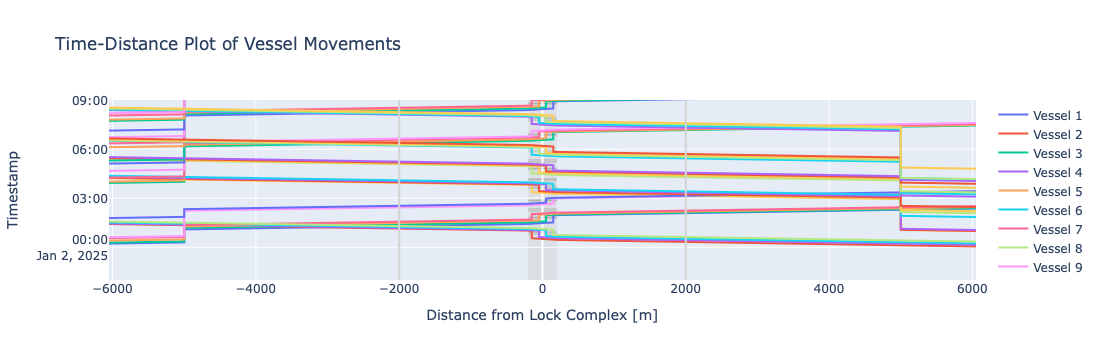

In [13]:
# We can plot the time-distance diagram
fig = lock.create_time_distance_plot(vessels = vessels, 
                                     xlimmin = -6050, 
                                     xlimmax = 6050,
                                     ylimmin = pd.Timestamp('2025-01-01 22:00:00'),
                                     ylimmax = pd.Timestamp('2025-01-02 09:00:00'),
                                     method='Plotly')
fig

In [14]:
lock.vessel_planning

,id,bound,L,B,T,operation_index,time_of_registration,time_of_acceptance,time_arrival_at_waiting_area,time_arrival_at_lineup_area,time_lock_passing_start,time_lock_entry_start,time_lock_entry_stop,time_lock_departure_start,time_lock_departure_stop,time_lock_passing_stop,delay,time_potential_lock_door_opening_stop,time_potential_lock_door_closure_start
0,bee5b44d-5314-40fb-8767-eea6f854a988,1,100,20,10,1,2025-01-01 00:07:22.177207,2025-01-01 00:07:22.177207,2025-01-02 00:07:22.177207,NaN,2025-01-02 00:19:52.177207,2025-01-02 00:27:22.177207,2025-01-02 00:33:02.349993470,2025-01-02 01:00:26.301059352,2025-01-02 01:01:14.897171704,2025-01-02 01:08:44.897171704,0 days 00:12:23.951065882,2025-01-02 00:17:22.177207000,2025-01-02 00:33:02.349993470
1,98b62c0f-4db5-4d02-abc8-3c1ae50fa297,1,100,20,10,1,2025-01-01 00:13:40.580269,2025-01-01 00:13:40.580269,2025-01-02 00:13:40.580269,NaN,2025-01-02 00:26:10.580269,2025-01-02 00:33:40.580269,2025-01-02 00:37:43.560830764,2025-01-02 01:00:49.108834646,2025-01-02 01:03:14.897171704,2025-01-02 01:10:44.897171704,0 days 00:07:42.740228588,2025-01-02 00:23:40.580269000,2025-01-02 00:37:43.560830764
2,2fb70e54-ae7a-4fca-bcb1-d1ebca721990,1,100,20,10,1,2025-01-01 00:17:13.532738,2025-01-01 00:17:13.532738,2025-01-02 00:17:13.532738,NaN,2025-01-02 00:31:10.580269,2025-01-02 00:38:40.580269,2025-01-02 00:41:06.368606058,2025-01-02 01:02:49.108834646,2025-01-02 01:06:52.089396410,2025-01-02 01:14:22.089396410,0 days 00:04:19.932453294,2025-01-02 00:28:40.580269000,2025-01-02 00:41:06.368606058
3,9f0b7307-e09f-49dc-8fd7-fb397e419d3c,0,100,20,10,2,2025-01-01 00:17:54.550491,2025-01-01 00:17:54.550491,2025-01-02 00:17:54.550491,NaT,2025-01-02 01:17:59.281621116,2025-01-02 01:25:29.281621116,2025-01-02 01:31:09.454407586,2025-01-02 01:56:58.050519938,2025-01-02 01:57:46.646632290,2025-01-02 02:05:16.646632290,0 days 00:58:23.327242468,2025-01-02 01:15:29.281621116,2025-01-02 01:31:09.454407586
4,7dc029fb-2baa-47de-bb61-481973f71dd3,0,100,20,10,2,2025-01-01 00:21:25.206401,2025-01-01 00:21:25.206401,2025-01-02 00:21:25.206401,NaT,2025-01-02 01:23:39.454407586,2025-01-02 01:31:09.454407586,2025-01-02 01:35:12.434969350,2025-01-02 01:57:20.858295232,2025-01-02 01:59:46.646632290,2025-01-02 02:07:16.646632290,0 days 00:14:42.740228588,2025-01-02 01:21:09.454407586,2025-01-02 01:35:12.434969350
5,d1489219-aef5-4cd9-aebd-0355e1771fe1,1,100,20,10,1,2025-01-01 00:24:37.704947,2025-01-01 00:24:37.704947,2025-01-02 00:24:37.704947,NaN,2025-01-02 00:37:07.704947,2025-01-02 00:44:37.704947,2025-01-02 00:45:26.301059352,2025-01-02 01:04:49.108834646,2025-01-02 01:10:29.281621116,2025-01-02 01:17:59.281621116,0 days 00:00:00,2025-01-02 00:34:37.704947000,2025-01-02 00:45:26.301059352
6,88516480-1115-4eb2-b502-2ea6ecfaab35,0,100,20,10,2,2025-01-01 00:28:58.436860,2025-01-01 00:28:58.436860,2025-01-02 00:28:58.436860,NaN,2025-01-02 01:28:39.454407586,2025-01-02 01:36:09.454407586,2025-01-02 01:38:35.242744644,2025-01-02 01:59:20.858295232,2025-01-02 02:03:23.838856996,2025-01-02 02:10:53.838856996,0 days 00:03:22.807775294,2025-01-02 01:26:09.454407586,2025-01-02 01:38:35.242744644
7,ff767275-868d-4501-8678-bddbe3600099,0,100,20,10,2,2025-01-01 00:38:12.774662,2025-01-01 00:38:12.774662,2025-01-02 00:38:12.774662,NaN,2025-01-02 01:33:39.454407586,2025-01-02 01:41:09.454407586,2025-01-02 01:41:58.050519938,2025-01-02 02:01:20.858295232,2025-01-02 02:07:01.031081702,2025-01-02 02:14:31.031081702,0 days 00:00:00,2025-01-02 01:31:09.454407586,2025-01-02 01:41:58.050519938
8,823a56d9-ac80-4586-a912-557fe852f572,0,100,20,10,4,2025-01-01 00:40:58.019450,2025-01-01 00:40:58.019450,2025-01-02 00:40:58.019450,NaN,2025-01-02 02:26:31.031081702,2025-01-02 02:34:01.031081702,2025-01-02 02:39:41.203868172,2025-01-02 02:58:44.184429936,2025-01-02 02:59:32.780542288,2025-01-02 03:07:02.780542288,0 days 01:37:05.992193466,2025-01-02 02:24:01.031081702,2025-01-02 02:39:41.203868172
9,9969478a-9e36-44f5-b7ba-a5702c51d507,1,100,20,10,5,20

In [15]:
lock.operation_planning

,bound,vessels,capacity_L,capacity_B,time_potential_lock_door_opening_stop,time_operation_start,time_entry_start,time_entry_stop,time_door_closing_start,time_door_closing_stop,...,time_door_opening_stop,time_departure_start,time_departure_stop,time_operation_stop,time_potential_lock_door_closure_start,wlev_A,wlev_B,maximum_individual_delay,total_delay,status
lock_operation,,,,,,,,,,,,,,,,,,,,,
0,0,[],400,50,2025-01-01 00:07:22.177207,2025-01-01 00:07:22.177207,2025-01-01 00:07:22.177207,2025-01-01 00:07:22.177207,2025-01-01 00:07:22.177207,2025-01-01 00:12:22.177207,...,2025-01-01 00:22:22.177207,2025-01-01 00:22:22.177207,2025-01-01 00:22:22.177207,2025-01-01 00:22:22.177207,2025-01-01 00:22:22.177207,NaN,NaN,0 days 00:00:00,0 days 00:00:00,available
1,1,"[<__main__.Vessel object at 0x179952d90>, <__m...",0,-30,2025-01-02 00:17:22.177207,2025-01-02 00:19:52.177207,2025-01-02 00:27:22.177207,2025-01-02 00:45:26.301059352,2025-01-02 00:45:26.301059352,2025-01-02 00:50:26.301059352,...,2025-01-02 01:00:26.301059352,2025-01-02 01:00:26.301059352,2025-01-02 01:10:29.281621116,2025-01-02 01:17:59.281621116,2025-01-02 01:12:29.281621116,NaN,NaN,0 days 00:12:23.951065882,0 days 00:24:26.623747764,unavailable
2,0,"[<__main__.Vessel object at 0x179951bd0>, <__m...",0,-30,2025-01-02 01:15:29.281621116,2025-01-02 01:17:59.281621116,2025-01-02 01:25:29.281621116,2025-01-02 01:41:58.050519938,2025-01-02 01:41:58.050519938,2025-01-02 01:46:58.050519938,...,2025-01-02 01:56:58.050519938,2025-01-02 01:56:58.050519938,2025-01-02 02:07:01.031081702,2025-01-02 02:14:31.031081702,2025-01-02 02:09:01.031081702,NaN,NaN,0 days 00:58:23.327242468,0 days 01:16:28.875246350,unavailable
3,1,[],400,50,2025-01-02 02:09:01.031081702,2025-01-02 02:09:01.031081702,2025-01-02 02:09:01.031081702,2025-01-02 02:09:01.031081702,2025-01-02 02:09:01.031081702,2025-01-02 02:14:01.031081702,...,2025-01-02 02:24:01.031081702,2025-01-02 02:24:01.031081702,2025-01-02 02:24:01.031081702,2025-01-02 02:24:01.031081702,2025-01-02 02:24:01.031081702,NaN,NaN,0 days 00:00:00,0 days 00:00:00,available
4,0,"[<__main__.Vessel object at 0x179965690>, <__m...",200,10,2025-01-02 02:24:01.031081702,2025-01-02 02:26:31.031081702,2025-01-02 02:34:01.031081702,2025-01-02 02:43:44.184429936,2025-01-02 02:43:44.184429936,2025-01-02 02:48:44.184429936,...,2025-01-02 02:58:44.184429936,2025-01-02 02:58:44.184429936,2025-01-02 03:01:32.780542288,2025-01-02 03:09:02.780542288,2025-01-02 03:03:32.780542288,NaN,NaN,0 days 01:37:05.992193466,0 days 01:37:05.992193466,unavailable
5,1,"[<__main__.Vessel object at 0x179963350>, <__m...",0,-30,2025-01-02 03:06:32.780542288,2025-01-02 03:09:02.780542288,2025-01-02 03:16:32.780542288,2025-01-02 03:33:01.549441110,2025-01-02 03:33:01.549441110,2025-01-02 03:38:01.549441110,...,2025-01-02 03:48:01.549441110,2025-01-02 03:48:01.549441110,2025-01-02 03:58:04.530002874,2025-01-02 04:05:34.530002874,2025-01-02 04:00:04.530002874,NaN,NaN,0 days 02:03:47.704890640,0 days 02:26:02.089340050,unavailable
6,0,[],400,50,2025-01-02 04:00:04.530002874,2025-01-02 04:00:04.530002874,2025-01-02 04:00:04.530002874,2025-01-02 04:00:04.530002874,2025-01-02 04:00:04.530002874,2025-01-02 04:05:04.530002874,...,2025-01-02 04:15:04.530002874,2025-01-02 04:15:04.530002874,2025-01-02 04:15:04.530002874,2025-01-02 04:15:04.530002874,2025-01-02 04:15:04.530002874,NaN,NaN,0 days 00:00:00,0 days 00:00:00,available
7,1,"[<__main__.Vessel object at 0x17997af90>, <__m...",0,-30,2025-01-02 04:15:04.530002874,2025-01-02 04:17:34.530002874,2025-01-02 04:25:04.530002874,2025-01-02 04:41:33.298901696,2025-01-02 04:41:33.298901696,2025-01-02 04:46:33.298901696,...,2025-01-02 04:56:33.298901696,2025-01-02 04:56:33.298901696,2025-01-02 05:06:36.279463460,2025-01-02 05:14:06.279463460,2025-01-02 05:08:36.279463460,NaN,NaN,0 days 02:06:38.730377226,0 days 02:16:47.153703108,unavailable
8,0,[],400,50,2025-01-02 05:08:36.279463460,2025-01-02 05:08:36.279463460,2025-01-02 05:08:36.279463460,2025-0

In [16]:
lock.operation_planning.apply(lambda x: [vessel.name for vessel in (x.vessels)], axis=1)

lock_operation
0                                               []
1         [Vessel 2, Vessel 4, Vessel 6, Vessel 8]
2         [Vessel 1, Vessel 3, Vessel 5, Vessel 7]
3                                               []
4                            [Vessel 9, Vessel 11]
5     [Vessel 10, Vessel 12, Vessel 14, Vessel 16]
6                                               []
7     [Vessel 18, Vessel 20, Vessel 22, Vessel 24]
8                                               []
9     [Vessel 26, Vessel 28, Vessel 30, Vessel 32]
10    [Vessel 13, Vessel 15, Vessel 17, Vessel 19]
11    [Vessel 34, Vessel 36, Vessel 38, Vessel 40]
12    [Vessel 21, Vessel 23, Vessel 25, Vessel 27]
13                                              []
14    [Vessel 29, Vessel 31, Vessel 33, Vessel 35]
15                                              []
16                          [Vessel 37, Vessel 39]
dtype: object

In [17]:
pd.DataFrame(vessels[0].logbook)

,Message,Timestamp,Value,Geometry
0,Sailing from node -1 to node 0 start,2025-01-01 00:17:54.550491,0,POINT (-3.149493386123042 0)
1,Sailing from node -1 to node 0 stop,2025-01-02 00:17:54.550491,345600.0,POINT (-0.0449157642059761 0)
2,Sailing from node 0 to node 1 start,2025-01-02 00:17:54.550491,345600.0,POINT (-0.0449157642059761 0)
3,Waiting for lock operation start,2025-01-02 00:17:54.550491,"{'origin': '', 'destination': '', 'route': [],...",POINT (-0.0449157642059761 0)
4,Waiting for lock operation stop,2025-01-02 01:05:29.281621,"{'origin': '', 'destination': '', 'route': [],...",POINT (-0.0449157642059761 0)
5,Sailing to first lock doors start,2025-01-02 01:05:29.281621,"{'origin': '', 'destination': '', 'route': [],...",POINT (-0.0449157642059761 0)
6,Sailing to first lock doors stop,2025-01-02 01:25:29.281621,"{'origin': '', 'destination': '', 'route': [],...",POINT (-0.001796630568239 0)
7,Sailing to position in lock start,2025-01-02 01:25:29.281621,"{'origin': '', 'destination': '', 'route': [],...",POINT (-0.001796630568239 0)
8,Sailing to position in lock stop,2025-01-02 01:31:09.454407,"{'origin': '', 'destination': '', 'route': [],...",POINT (0.0013474729261793 0)
9,Waiting for other vessels in lock start,2025-01-02 01:31:09.454407,{},POINT (0.0013474729261793 0)


In [18]:
delays = []
for vessel in vessels:
    vessel_df = pd.DataFrame(vessel.logbook)
    waiting_stop = vessel_df[vessel_df.Message == "Waiting stop"]
    if not waiting_stop.empty:
        delay = (waiting_stop.Timestamp-vessel.metadata["arrival_time"]).iloc[0]
    else:
        delay = pd.Timedelta(seconds=0)
    delays.append(delay)

In [19]:
print(f"The average vessel delay is {np.round(np.average(delays).total_seconds()/60,1)} minutes")

The average vessel delay is 0.0 minutes


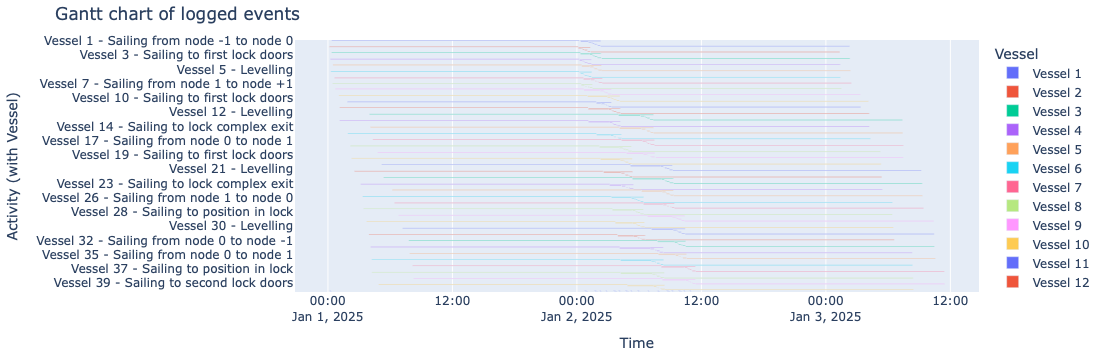

In [20]:
df_eventtable = opentnsim.core.logutils.logbook2eventtable([*vessels, lock])
generate_vessel_gantt_chart(df_eventtable)

#### Thinking of a way to analyse Intensity
'get_vessels_during_leveling':
- Identify locking cycles (by looking at the lock logbook)
- From the vessel list identify which vessels were in the lock during that locking cycle

'calculate_cycle_looptimes':
- Using the info derived from 'get_vessels_during_leveling' calculate looptimes

'calculate_detailed_cycle_time':
- using the info from 'get_vessels_during_leveling' and 'calculate_cycle_looptimes' calculate detailed cycle times

In [21]:
leveling_cycles = opentnsim.lock.logutils.get_vessels_during_leveling(lock, vessels)
looptimes_df = opentnsim.lock.logutils.calculate_cycle_looptimes(leveling_cycles, vessels)
Tc_df = opentnsim.lock.logutils.calculate_detailed_cycle_time(lock, vessels, leveling_cycles)

display(pd.DataFrame(leveling_cycles))
display(looptimes_df)
display(Tc_df)

,leveling_start,leveling_stop,vessels_present
0,2025-01-01 00:12:22.177207,2025-01-01 00:17:22.177207,[]
1,2025-01-02 00:50:26.301059,2025-01-02 00:55:26.301059,"[Vessel 2, Vessel 4, Vessel 6, Vessel 8]"
2,2025-01-02 01:46:58.050519,2025-01-02 01:51:58.050519,"[Vessel 1, Vessel 3, Vessel 5, Vessel 7]"
3,2025-01-02 02:14:01.031082,2025-01-02 02:19:01.031082,[]
4,2025-01-02 02:48:44.184430,2025-01-02 02:53:44.184430,"[Vessel 9, Vessel 11]"
5,2025-01-02 03:38:02.000000,2025-01-02 03:43:02.000000,"[Vessel 10, Vessel 12, Vessel 14, Vessel 16]"
6,2025-01-02 04:05:04.980561,2025-01-02 04:10:04.980561,[]
7,2025-01-02 04:46:33.298901,2025-01-02 04:51:33.298901,"[Vessel 18, Vessel 20, Vessel 22, Vessel 24]"
8,2025-01-02 05:13:36.279463,2025-01-02 05:18:36.279463,[]
9,2025-01-02 05:55:05.048361,2025-01-02 06:00:05.048361,"[Vessel 26, Vessel 28, Vessel 30, Vessel 32]"


,cycle,looptime_seconds
0,1,0.000000
1,2,NaN
2,3,900.000000
3,4,NaN
4,5,NaN
5,6,900.000000
6,7,NaN
7,8,NaN
8,9,NaN
9,10,NaN


,t_l_up,sum_t_i_up,T_close_up,T_waterlevel_up,T_open_up,sum_t_u_up,t_l_down,sum_t_i_down,T_close_down,T_waterlevel_down,T_open_down,sum_t_u_down,Tc_seconds,up_vessels,down_vessels,I_s
0,0.000000,0.000000,300.0,300.0,300.0,0.000000,0.000000,1084.123852,300.0,300.0,300.0,602.980562,3487.104414,[],"[Vessel 2, Vessel 4, Vessel 6, Vessel 8]",4.129501
1,900.000000,988.768898,300.0,300.0,300.0,602.980563,0.000000,0.000000,300.0,300.0,300.0,0.000000,4291.749461,"[Vessel 1, Vessel 3, Vessel 5, Vessel 7]",[],3.355275
2,0.000000,583.153349,300.0,300.0,300.0,168.596112,900.000000,988.768898,300.0,300.0,300.0,602.980561,5043.498920,"[Vessel 9, Vessel 11]","[Vessel 10, Vessel 12, Vessel 14, Vessel 16]",4.282741
3,0.000000,0.000000,300.0,300.0,300.0,0.000000,0.000000,988.768899,300.0,300.0,300.0,602.980562,3391.749461,[],"[Vessel 18, Vessel 20, Vessel 22, Vessel 24]",4.245597
4,0.000000,0.000000,300.0,300.0,300.0,0.000000,0.000000,988.768898,300.0,300.0,300.0,602.980562,3391.749460,[],"[Vessel 26, Vessel 28, Vessel 30, Vessel 32]",4.245597
5,900.000000,988.768898,300.0,300.0,300.0,602.980561,899.797823,988.768899,300.0,300.0,300.0,602.980561,6783.296742,"[Vessel 13, Vessel 15, Vessel 17, Vessel 19]","[Vessel 34, Vessel 36, Vessel 38, Vessel 40]",4.245723
6,899.547284,988.768898,300.0,300.0,300.0,602.980562,0.000000,0.000000,300.0,300.0,300.0,0.000000,4291.296744,"[Vessel 21, Vessel 23, Vessel 25, Vessel 27]",[],3.355629
7,0.000000,988.768899,300.0,300.0,300.0,602.980562,0.000000,0.000000,300.0,300.0,300.0,0.000000,3391.749461,"[Vessel 29, Vessel 31, Vessel 33, Vessel 35]",[],4.245597


In [22]:
for index, row in Tc_df.iterrows():
    print('Locking cycle {} has an intensity of {:.2f} vessels per hour'.format(index+1, row['I_s']))

Locking cycle 1 has an intensity of 4.13 vessels per hour
Locking cycle 2 has an intensity of 3.36 vessels per hour
Locking cycle 3 has an intensity of 4.28 vessels per hour
Locking cycle 4 has an intensity of 4.25 vessels per hour
Locking cycle 5 has an intensity of 4.25 vessels per hour
Locking cycle 6 has an intensity of 4.25 vessels per hour
Locking cycle 7 has an intensity of 3.36 vessels per hour
Locking cycle 8 has an intensity of 4.25 vessels per hour


In [23]:
lock.operation_planning

,bound,vessels,capacity_L,capacity_B,time_potential_lock_door_opening_stop,time_operation_start,time_entry_start,time_entry_stop,time_door_closing_start,time_door_closing_stop,...,time_door_opening_stop,time_departure_start,time_departure_stop,time_operation_stop,time_potential_lock_door_closure_start,wlev_A,wlev_B,maximum_individual_delay,total_delay,status
lock_operation,,,,,,,,,,,,,,,,,,,,,
0,0,[],400,50,2025-01-01 00:07:22.177207,2025-01-01 00:07:22.177207,2025-01-01 00:07:22.177207,2025-01-01 00:07:22.177207,2025-01-01 00:07:22.177207,2025-01-01 00:12:22.177207,...,2025-01-01 00:22:22.177207,2025-01-01 00:22:22.177207,2025-01-01 00:22:22.177207,2025-01-01 00:22:22.177207,2025-01-01 00:22:22.177207,NaN,NaN,0 days 00:00:00,0 days 00:00:00,available
1,1,"[<__main__.Vessel object at 0x179952d90>, <__m...",0,-30,2025-01-02 00:17:22.177207,2025-01-02 00:19:52.177207,2025-01-02 00:27:22.177207,2025-01-02 00:45:26.301059352,2025-01-02 00:45:26.301059352,2025-01-02 00:50:26.301059352,...,2025-01-02 01:00:26.301059352,2025-01-02 01:00:26.301059352,2025-01-02 01:10:29.281621116,2025-01-02 01:17:59.281621116,2025-01-02 01:12:29.281621116,NaN,NaN,0 days 00:12:23.951065882,0 days 00:24:26.623747764,unavailable
2,0,"[<__main__.Vessel object at 0x179951bd0>, <__m...",0,-30,2025-01-02 01:15:29.281621116,2025-01-02 01:17:59.281621116,2025-01-02 01:25:29.281621116,2025-01-02 01:41:58.050519938,2025-01-02 01:41:58.050519938,2025-01-02 01:46:58.050519938,...,2025-01-02 01:56:58.050519938,2025-01-02 01:56:58.050519938,2025-01-02 02:07:01.031081702,2025-01-02 02:14:31.031081702,2025-01-02 02:09:01.031081702,NaN,NaN,0 days 00:58:23.327242468,0 days 01:16:28.875246350,unavailable
3,1,[],400,50,2025-01-02 02:09:01.031081702,2025-01-02 02:09:01.031081702,2025-01-02 02:09:01.031081702,2025-01-02 02:09:01.031081702,2025-01-02 02:09:01.031081702,2025-01-02 02:14:01.031081702,...,2025-01-02 02:24:01.031081702,2025-01-02 02:24:01.031081702,2025-01-02 02:24:01.031081702,2025-01-02 02:24:01.031081702,2025-01-02 02:24:01.031081702,NaN,NaN,0 days 00:00:00,0 days 00:00:00,available
4,0,"[<__main__.Vessel object at 0x179965690>, <__m...",200,10,2025-01-02 02:24:01.031081702,2025-01-02 02:26:31.031081702,2025-01-02 02:34:01.031081702,2025-01-02 02:43:44.184429936,2025-01-02 02:43:44.184429936,2025-01-02 02:48:44.184429936,...,2025-01-02 02:58:44.184429936,2025-01-02 02:58:44.184429936,2025-01-02 03:01:32.780542288,2025-01-02 03:09:02.780542288,2025-01-02 03:03:32.780542288,NaN,NaN,0 days 01:37:05.992193466,0 days 01:37:05.992193466,unavailable
5,1,"[<__main__.Vessel object at 0x179963350>, <__m...",0,-30,2025-01-02 03:06:32.780542288,2025-01-02 03:09:02.780542288,2025-01-02 03:16:32.780542288,2025-01-02 03:33:01.549441110,2025-01-02 03:33:01.549441110,2025-01-02 03:38:01.549441110,...,2025-01-02 03:48:01.549441110,2025-01-02 03:48:01.549441110,2025-01-02 03:58:04.530002874,2025-01-02 04:05:34.530002874,2025-01-02 04:00:04.530002874,NaN,NaN,0 days 02:03:47.704890640,0 days 02:26:02.089340050,unavailable
6,0,[],400,50,2025-01-02 04:00:04.530002874,2025-01-02 04:00:04.530002874,2025-01-02 04:00:04.530002874,2025-01-02 04:00:04.530002874,2025-01-02 04:00:04.530002874,2025-01-02 04:05:04.530002874,...,2025-01-02 04:15:04.530002874,2025-01-02 04:15:04.530002874,2025-01-02 04:15:04.530002874,2025-01-02 04:15:04.530002874,2025-01-02 04:15:04.530002874,NaN,NaN,0 days 00:00:00,0 days 00:00:00,available
7,1,"[<__main__.Vessel object at 0x17997af90>, <__m...",0,-30,2025-01-02 04:15:04.530002874,2025-01-02 04:17:34.530002874,2025-01-02 04:25:04.530002874,2025-01-02 04:41:33.298901696,2025-01-02 04:41:33.298901696,2025-01-02 04:46:33.298901696,...,2025-01-02 04:56:33.298901696,2025-01-02 04:56:33.298901696,2025-01-02 05:06:36.279463460,2025-01-02 05:14:06.279463460,2025-01-02 05:08:36.279463460,NaN,NaN,0 days 02:06:38.730377226,0 days 02:16:47.153703108,unavailable
8,0,[],400,50,2025-01-02 05:08:36.279463460,2025-01-02 05:08:36.279463460,2025-01-02 05:08:36.279463460,2025-0